# LV Ablations Notebook

This notebook is the notebook version of the Lotka--Volterra ablation plots, adapted to this repo layout. It reads saved ablation `.npz` files from `ablations/`, renders figures inline, and saves the main ablation figures to `figures/`.


In [148]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
ABLATIONS_DIR = ROOT / "ablations"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

STEP_OUTPUT = FIGURES_DIR / "lv_step_size_ablation.pdf"
DECAY_OUTPUT = FIGURES_DIR / "lv_decay_ablation.pdf"
MN_OUTPUT = FIGURES_DIR / "lv_mn_theta_error_boxplots.pdf"
LENGTHSCALE_OUTPUT = FIGURES_DIR / "lv_lengthscale_pair_ablation.pdf"
SUMMARY_OUTPUT = FIGURES_DIR / "lv_ablation_summary.pdf"

FIGSIZE = (6, 4)
SUMMARY_DPI = 150
TITLE_SIZE = 28
LABEL_SIZE = 26
TICK_SIZE = 22
LEGEND_SIZE = 20
LINE_WIDTH = 2.0
TITLE_PAD = 8
COLORS = {
    "gd": "#1b9e77",
    "pgd": "#d95f02",
}
BOX_COLORS = [
    "#4c78a8",
    "#e45756",
    "#72b7b2",
    "#b279a2",
    "#ff9da6",
    "#9d755d",
    "#bab0ab",
]

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DejaVu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "legend.frameon": False,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "lines.linewidth": LINE_WIDTH,
    "figure.figsize": FIGSIZE,
    "figure.dpi": 100,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)


def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _save_figure(fig, output_path=None, **savefig_kwargs):
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, **savefig_kwargs)
    return fig


def _make_single_color_boxplot(ax, series, labels, color, xlabel, ylabel, title=None, logy=True):
    bp = ax.boxplot(series, patch_artist=True, widths=0.6)
    palette = BOX_COLORS
    for idx, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(palette[idx % len(palette)])
        patch.set_alpha(0.8)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2.0)
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, pad=TITLE_PAD)
    if logy:
        ax.set_yscale("log")
    return bp


def _theta_error_series_lv(npz_path):
    data = _load_npz_dict(npz_path)
    theta_true = np.asarray(data["theta_true"], dtype=float)
    theta_finals = np.asarray(data["pgd_theta_finals"], dtype=float)
    return np.linalg.norm(theta_finals - theta_true[None, :], axis=1)


def make_lv_step_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"lotka_volterra_step_size_ablation_pgd_gamma_sweep_(?P<gamma>[^_]+)\.npz$")
    collected = []
    for npz_path in sorted(results_dir.glob("lotka_volterra_step_size_ablation_pgd_gamma_sweep_*.npz")):
        if npz_path.name.endswith("_summary.npz"):
            continue
        match = pattern.match(npz_path.name)
        if match is None:
            continue
        gamma = float(match.group("gamma").replace("p", ".").replace("m", "-"))
        data = _load_npz_dict(npz_path)
        collected.append((gamma, _theta_error_series_lv(npz_path)))
    collected.sort(key=lambda item: item[0])
    labels = [f"{gamma:g}" for gamma, _ in collected]
    series = [values for _, values in collected]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "Stepsize," r" $\gamma$", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_lv_decay_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"lotka_volterra_decay_ablation_pgd_decay_sweep_(?P<decay>[^_]+)\.npz$")
    collected = []
    for npz_path in sorted(results_dir.glob("lotka_volterra_decay_ablation_pgd_decay_sweep_*.npz")):
        if npz_path.name.endswith("_summary.npz"):
            continue
        match = pattern.match(npz_path.name)
        if match is None:
            continue
        decay = float(match.group("decay").replace("p", ".").replace("m", "-"))
        data = _load_npz_dict(npz_path)
        collected.append((decay, _theta_error_series_lv(npz_path)))
    collected.sort(key=lambda item: item[0])
    labels = [f"{decay:g}" for decay, _ in collected]
    series = [values for _, values in collected]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "Decay rate", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def _collect_lv_mn_theta_errors(results_dir):
    pattern = re.compile(r"lotka_volterra_observation_model_grid_m_(?P<m>[^_]+)_n_(?P<n>[^_]+)\.npz$")
    by_mn = {}
    m_values = set()
    n_values = set()
    for npz_path in sorted(results_dir.glob("lotka_volterra_observation_model_grid_m_*_n_*.npz")):
        match = pattern.match(npz_path.name)
        if match is None:
            continue
        m = float(match.group("m").replace("p", ".").replace("m", "-"))
        n = float(match.group("n").replace("p", ".").replace("m", "-"))
        by_mn[(m, n)] = _theta_error_series_lv(npz_path)
        m_values.add(m)
        n_values.add(n)
    return by_mn, sorted(m_values), sorted(n_values)


def make_lv_mn_boxplots(results_dir, output_path=None):
    by_mn, m_values, n_values = _collect_lv_mn_theta_errors(results_dir)
    grouped_by_n = [np.concatenate([by_mn[(m, n)] for m in m_values]) for n in n_values]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(
            ax,
            grouped_by_n,
            [f"{n:g}" for n in n_values],
            "#4c78a8",
            r"Model samples, $n$",
            r"$\Vert\theta_{\mathrm{final}} - \theta_{\mathrm{true}}\Vert_2$",
            # title="PGD grouped by n",
            logy=True,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_lv_lengthscale_ridge_heatmap(summary_path, output_path=None):
    summary = _load_npz_dict(summary_path)
    theta_mean_grid = np.asarray(summary["pgd_theta_mean_grid"], dtype=float)
    ell_values = np.asarray(summary["lengthscale_values"], dtype=float)
    lambda_values = np.asarray(summary["lambda_scales"], dtype=float)
    output_paths = np.asarray(summary["output_paths"])
    sample_output = Path(output_paths.flat[0])
    if not sample_output.exists():
        sample_output = summary_path.parent / sample_output.name
    if not sample_output.exists():
        raise FileNotFoundError(f"Could not resolve a sample LV heatmap run file from {summary_path}")
    run_data = _load_npz_dict(sample_output)
    theta_true = np.asarray(run_data["theta_true"], dtype=float)
    error_grid = np.linalg.norm(theta_mean_grid - theta_true[None, None, :], axis=-1)
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.0, 5.0), dpi=SUMMARY_DPI)
        im = ax.imshow(error_grid, cmap="viridis", aspect="auto")
        ax.set_xticks(np.arange(len(ell_values)))
        ax.set_yticks(np.arange(len(lambda_values)))
        ax.set_xticklabels([f"{value:g}" for value in ell_values])
        ax.set_yticklabels([f"{value:g}" for value in lambda_values])
        ax.set_xlabel(r"$\ell_{\infty}$")
        ax.set_ylabel("")
        ax.grid(False)
        for i in range(error_grid.shape[0]):
            for j in range(error_grid.shape[1]):
                ax.text(j, i, f"{error_grid[i, j]:.2e}", ha="center", va="center", color="white", fontsize=12)
        cbar = fig.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=TICK_SIZE)
        cbar.set_label(r"$\|\bar{\theta}_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$", rotation=270, labelpad=24, fontsize=LABEL_SIZE)
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_lv_cross_method_comparison(npz_path, output_path=None):
    data = _load_npz_dict(npz_path)
    required = [
        "sgd_theta_histories",
        "pgd_theta_histories",
        "theta_true",
        "sgd_history_steps",
        "pgd_history_steps",
        "adaptive_sgd_theta_histories",
        "fixed_pgd_theta_histories",
        "adaptive_sgd_history_steps",
        "fixed_pgd_history_steps",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError(
            "Missing keys for LV cross-method comparison: " + ", ".join(missing)
        )

    theta_true = np.asarray(data["theta_true"], dtype=float)

    def theta_err(histories_key):
        histories = np.asarray(data[histories_key], dtype=float)
        return np.linalg.norm(histories - theta_true[None, None, :], axis=-1)

    sgd_err = theta_err("sgd_theta_histories")
    adaptive_sgd_err = theta_err("adaptive_sgd_theta_histories")
    pgd_err = theta_err("pgd_theta_histories")
    fixed_pgd_err = theta_err("fixed_pgd_theta_histories")

    sgd_steps = np.asarray(data["sgd_history_steps"], dtype=float) + 1.0
    adaptive_sgd_steps = np.asarray(data["adaptive_sgd_history_steps"], dtype=float) + 1.0
    pgd_steps = np.asarray(data["pgd_history_steps"], dtype=float) + 1.0
    fixed_pgd_steps = np.asarray(data["fixed_pgd_history_steps"], dtype=float) + 1.0

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.2, 5.0), dpi=SUMMARY_DPI)


        ax.plot(sgd_steps, np.mean(sgd_err, axis=0), color=COLORS["gd"], label="SGD fixed $\ell$")
        ax.plot(adaptive_sgd_steps, np.mean(adaptive_sgd_err, axis=0), color="#4c78a8", label="SGD adaptive $\ell$")
        ax.plot(pgd_steps, np.mean(pgd_err, axis=0), color=COLORS["pgd"], label="PGD adaptive $\ell$")
        ax.plot(fixed_pgd_steps, np.mean(fixed_pgd_err, axis=0), color="#ff9da6", label="PGD fixed $\ell$")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        ax.set_title("Cross-method comparison", pad=TITLE_PAD)
        ax.legend(loc="best")

        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def _collect_lv_series_from_pattern(results_dir, pattern):
    collected = []
    for npz_path in sorted(results_dir.glob(pattern)):
        if npz_path.name.endswith("_summary.npz"):
            continue
        match = re.search(r"([-0-9mp]+)\.npz$", npz_path.name)
        if match is None:
            continue
        value = float(match.group(1).replace("p", ".").replace("m", "-"))
        collected.append((value, _theta_error_series_lv(npz_path)))
    collected.sort(key=lambda item: item[0])
    return collected


def _draw_lv_step_boxplot(ax, results_dir):
    collected = _collect_lv_series_from_pattern(results_dir, "lotka_volterra_step_size_ablation_pgd_gamma_sweep_*.npz")
    _make_single_color_boxplot(
        ax,
        [values for _, values in collected],
        [f"{value:g}" for value, _ in collected],
        COLORS["pgd"],
        "Stepsize," r" $\gamma$",
        r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$",
        title="Step size",
        logy=True,
    )


def _draw_lv_decay_boxplot(ax, results_dir):
    collected = _collect_lv_series_from_pattern(results_dir, "lotka_volterra_decay_ablation_pgd_decay_sweep_*.npz")
    _make_single_color_boxplot(
        ax,
        [values for _, values in collected],
        [f"{value:g}" for value, _ in collected],
        COLORS["pgd"],
        "Decay rate",
        "",
        title="Decay",
        logy=True,
    )


def _draw_lv_mn_boxplot(ax, results_dir):
    by_mn, m_values, n_values = _collect_lv_mn_theta_errors(results_dir)
    grouped_by_n = [np.concatenate([by_mn[(m, n)] for m in m_values]) for n in n_values]
    _make_single_color_boxplot(
        ax,
        grouped_by_n,
        [f"{n:g}" for n in n_values],
        "#4c78a8",
        r"Model samples, $n$",
        "",
        title="m/n",
        logy=True,
    )


def _draw_lv_lengthscale_heatmap(ax, summary_path, fig):
    summary = _load_npz_dict(summary_path)
    theta_mean_grid = np.asarray(summary["pgd_theta_mean_grid"], dtype=float)
    ell_values = np.asarray(summary["lengthscale_values"], dtype=float)
    lambda_values = np.asarray(summary["lambda_scales"], dtype=float)
    output_paths = np.asarray(summary["output_paths"])
    sample_output = Path(output_paths.flat[0])
    if not sample_output.exists():
        sample_output = summary_path.parent / sample_output.name
    run_data = _load_npz_dict(sample_output)
    theta_true = np.asarray(run_data["theta_true"], dtype=float)
    error_grid = np.linalg.norm(theta_mean_grid - theta_true[None, None, :], axis=-1)
    im = ax.imshow(error_grid, cmap="viridis", aspect="auto")
    ax.set_xticks(np.arange(len(ell_values)))
    ax.set_yticks(np.arange(len(lambda_values)))
    ax.set_xticklabels([f"{value:g}" for value in ell_values])
    ax.set_yticklabels([f"{value:g}" for value in lambda_values])
    ax.set_xlabel(r"$\ell_{\infty}$")
    ax.set_ylabel(r"$\lambda$")
    ax.set_title("Lengthscale vs ridge", pad=TITLE_PAD)
    ax.grid(False)
    for i in range(error_grid.shape[0]):
        for j in range(error_grid.shape[1]):
            ax.text(j, i, f"{error_grid[i, j]:.2e}", ha="center", va="center", color="white", fontsize=10)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=TICK_SIZE)
    # cbar.set_label(r"$\|\bar{\theta}_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$", rotation=270, labelpad=22, fontsize=LABEL_SIZE)


def make_lv_ablation_summary(lv_step_dir, lv_decay_dir, lv_mn_dir, lv_lengthscale_summary, output_path=None, figsize=(24, 5), dpi=150):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(1, 4, figsize=figsize, dpi=dpi, gridspec_kw={"width_ratios": [1.0, 1.0, 1.0, 1.18]})
        _draw_lv_step_boxplot(axes[0], lv_step_dir)
        _draw_lv_decay_boxplot(axes[1], lv_decay_dir)
        _draw_lv_mn_boxplot(axes[2], lv_mn_dir)
        _draw_lv_lengthscale_heatmap(axes[3], lv_lengthscale_summary, fig)
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


## Local file setup

These defaults match the saved Lotka--Volterra ablation files that currently exist in this repo.


In [149]:
lv_step_dir = ABLATIONS_DIR / "lv_gamma"
lv_decay_dir = ABLATIONS_DIR / "lv_decay"
lv_mn_dir = ABLATIONS_DIR / "lv_mn_grid"
lv_lengthscale_summary = ABLATIONS_DIR / "lv_heatmap" / "history" / "lotka_volterra_lengthscale_regularization_grid_pgd_ell_min_summary.npz"
lv_compare_npz = ROOT / "lotka_volterra_results_pgd_vs_sgd.npz"

{
    "lv_step_dir": lv_step_dir,
    "lv_decay_dir": lv_decay_dir,
    "lv_mn_dir": lv_mn_dir,
    "lv_lengthscale_summary": lv_lengthscale_summary,
    "lv_compare_npz": lv_compare_npz,
    "outputs": [STEP_OUTPUT, DECAY_OUTPUT, MN_OUTPUT, LENGTHSCALE_OUTPUT],
}


{'lv_step_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma'),
 'lv_decay_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_decay'),
 'lv_mn_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_mn_grid'),
 'lv_lengthscale_summary': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_heatmap/history/lotka_volterra_lengthscale_regularization_grid_pgd_ell_min_summary.npz'),
 'lv_compare_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/lotka_volterra_results_pgd_vs_sgd.npz'),
 'outputs': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_step_size_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_decay_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_mn_theta_error_boxplots.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_lengthscale_pair_ablation.pdf')]}

In [150]:
available_inputs = {
    "lv_step_files": [path for path in lv_step_dir.glob("lotka_volterra_step_size_ablation_pgd_gamma_sweep_*.npz") if not path.name.endswith("_summary.npz")],
    "lv_decay_files": [path for path in lv_decay_dir.glob("lotka_volterra_decay_ablation_pgd_decay_sweep_*.npz") if not path.name.endswith("_summary.npz")],
    "lv_mn_files": list(lv_mn_dir.glob("lotka_volterra_observation_model_grid_m_*_n_*.npz")),
    "lv_lengthscale_summary": lv_lengthscale_summary.exists(),
    "lv_compare_npz": lv_compare_npz.exists(),
}
available_inputs


{'lv_step_files': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_300.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_100.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_10.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_1.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_gamma/lotka_volterra_step_size_ablation_pgd_gamma_sweep_30.npz')],
 'lv_decay_files': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_decay/lotka_volterra_decay_ablation_pgd_decay_sweep_0p5.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/lv_decay/lotka_volterra_decay_ablation_pgd_decay_sweep_0p9.npz'),
  PosixPath('/Users/sophiakang/

Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_ablation_summary.pdf


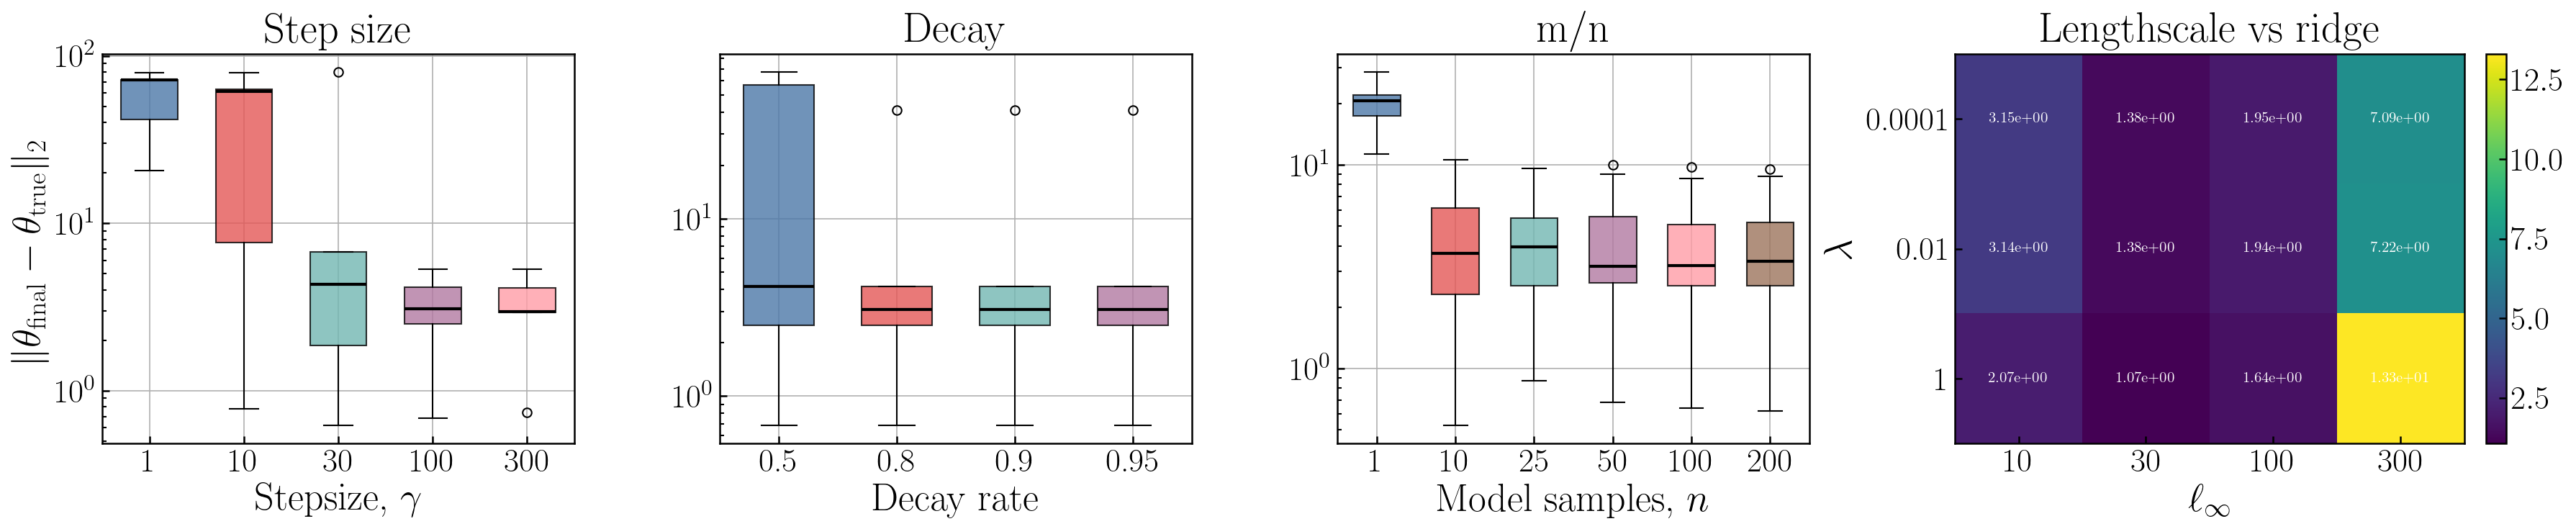

In [151]:
required_inputs = [
    *[path for path in lv_step_dir.glob("lotka_volterra_step_size_ablation_pgd_gamma_sweep_*.npz") if not path.name.endswith("_summary.npz")],
    *[path for path in lv_decay_dir.glob("lotka_volterra_decay_ablation_pgd_decay_sweep_*.npz") if not path.name.endswith("_summary.npz")],
    *list(lv_mn_dir.glob("lotka_volterra_observation_model_grid_m_*_n_*.npz")),
    lv_lengthscale_summary,
]
missing_inputs = [path for path in required_inputs if not Path(path).exists()]

if not missing_inputs:
    fig = make_lv_ablation_summary(
        lv_step_dir=lv_step_dir,
        lv_decay_dir=lv_decay_dir,
        lv_mn_dir=lv_mn_dir,
        lv_lengthscale_summary=lv_lengthscale_summary,
        output_path=None,
        figsize=(24, 5),
        dpi=SUMMARY_DPI,
    )
    fig.savefig(SUMMARY_OUTPUT, bbox_inches="tight")
    print(f"Saved figure to {SUMMARY_OUTPUT}")
    display(fig)
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )
